Graph loaded successfully.
[3.0, 3.0, 3.0, 5.0, 5.0, 7.0, 3.0, 3.0, 5.0, 5.0, 8.0, 5.0, 3.0, 5.0, 7.0, 7.0, 8.0, 3.0, 7.0, 7.0]
[3.   4.25 5.5  6.75 8.  ]


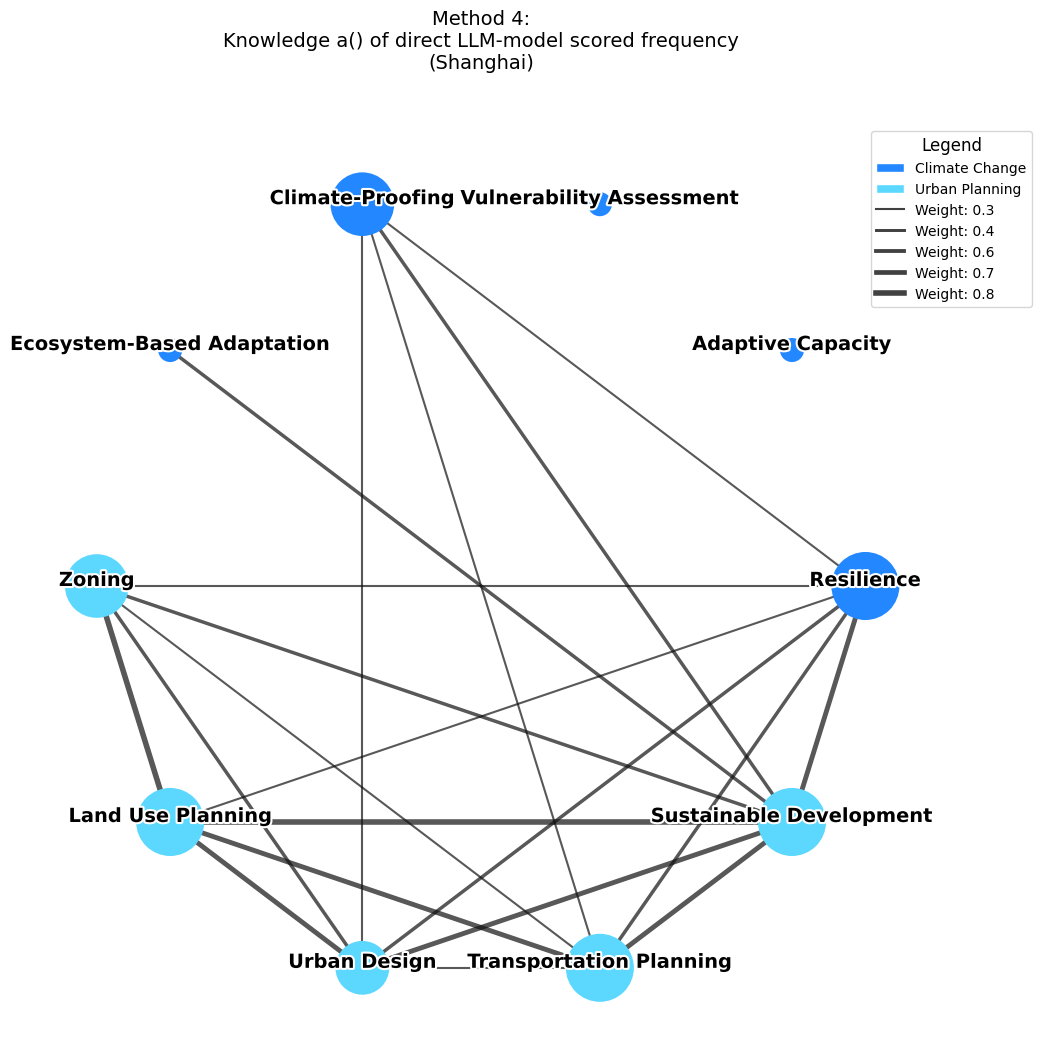

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import textwrap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_Shanghai_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': '#2388FF',
    'urban planning': '#5CD8FF'
}
j=300
m=2
k=10
# 获取节点属性
node_sizes = [attributes['weight'] * j for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]

# 过滤掉权重为1的边
edges_to_remove = [(u, v) for u, v in graph.edges if graph[u][v].get('weight', 1) == 1]
graph.remove_edges_from(edges_to_remove)

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 绘制节点
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)
# 绘制边，使用原始边权重作为线宽
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]
nx.draw_networkx_edges(
    graph, pos,
    width=[edge_weight/m for edge_weight in edge_weights],
    edge_color="#111111",
    alpha=0.7
)
# 取消 nx.draw_networkx_labels，直接用自定义文本绘制
# nx.draw_networkx_labels(graph, pos, labels={node: node.upper() for node in fixed_node_list}, font_size=14)

# 使用自定义标签绘制
for node, (x, y) in pos.items():
    # 获取节点名称并转为大写
    label = node.title()

    # 绘制节点标签并添加白色描边
    text = plt.text(
        x, y, label, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 白色描边
        path_effects.Normal()  # 恢复正常文字颜色
    ])

# 获取原始的边权重
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]
print(edge_weights)

# 在每条边的中间添加权重标签
edge_labels = {(u, v): f'{graph[u][v].get("weight", 1):.2f}' for u, v in graph.edges}

# 01创建线条粗细的图例
# 获取所有边的权重值
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]

# 生成用于图例的示例边权重
min_weight, max_weight = min(edge_weights), max(edge_weights)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]

# 创建一组权重值，用于生成图例（根据实际情况，可以选择几个代表性的权重值）
# 这里我们选择最小、中间和最大的权重值
legend_weights = np.linspace(min_weight, max_weight, 5)  # 图例中示例的边权重
legend_widths = [weight / m for weight in legend_weights]  # 与实际绘图的宽度计算一致

print(legend_weights)

edges_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in legend_weights]
edges_labels = [f'Edge Weight: {width*k}' for width in legend_weights]  # 图例标签
# 生成用于图例的示例边权重
example_weights = np.linspace(min_weight, max_weight, 6)  # 生成五个等间隔的权重
example_widths = [
    0.1 + (w - min_weight) / (max_weight - min_weight) * 1 for w in example_weights
]
# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]

# 添加边权重示例
for w, width in zip(legend_weights, legend_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w/10:.1f}"
        )
    )

# 绘制图例
plt.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.1, 1),
    fontsize=10,
    title="Legend",
    title_fontsize=12,
    frameon=True,
)

# 显示图形
plt.title("Method 4:\nKnowledge a() of direct LLM-model scored frequency\n(Shanghai)", fontsize=14, pad=40)
plt.axis('off')
plt.show()


Graph loaded successfully.
[3.0, 3.0, 3.0, 5.0, 5.0, 7.0, 3.0, 3.0, 5.0, 5.0, 8.0, 5.0, 3.0, 5.0, 7.0, 7.0, 8.0, 3.0, 7.0, 7.0]
[3.   4.25 5.5  6.75 8.  ]


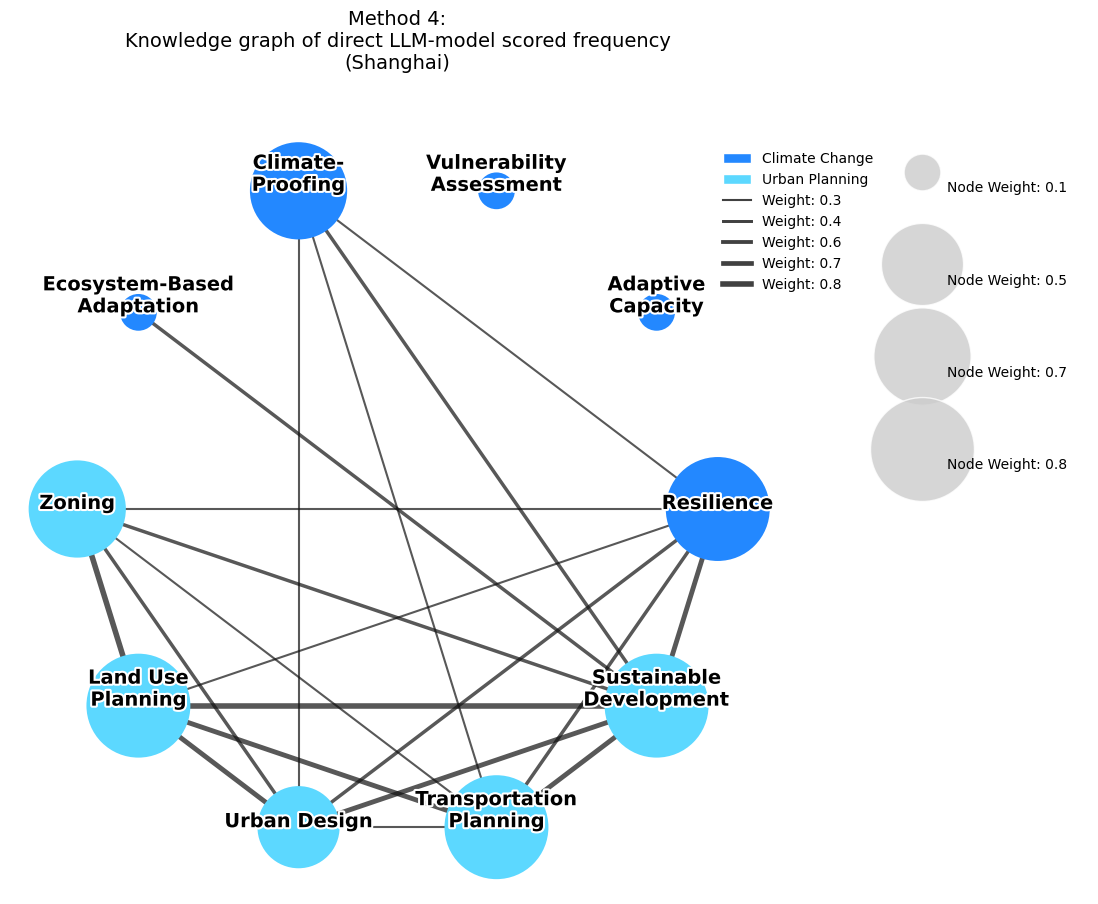

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import textwrap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_Shanghai_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': '#2388FF',
    'urban planning': '#5CD8FF'
}
j=700
m=2
k=20
# 获取节点属性
node_sizes = [attributes['weight'] * j for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]

# 过滤掉权重为1的边
edges_to_remove = [(u, v) for u, v in graph.edges if graph[u][v].get('weight', 1) == 1]
graph.remove_edges_from(edges_to_remove)

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 绘制节点
plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)

# 绘制边，使用原始边权重作为线宽
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]
nx.draw_networkx_edges(
    graph, pos,
    width=[edge_weight/m for edge_weight in edge_weights],
    edge_color="#111111",
    alpha=0.7
)
# 取消 nx.draw_networkx_labels，直接用自定义文本绘制
# nx.draw_networkx_labels(graph, pos, labels={node: node.upper() for node in fixed_node_list}, font_size=14)

# 使用自定义标签绘制
for node, (x, y) in pos.items():
    # 获取节点名称并转为大写
    label = node.title()
    # 自动按空格换行，限制每行最大字符数（例如：15个字符）
    wrapped_label = "\n".join(textwrap.wrap(label, width=15))
    # 绘制节点标签并添加白色描边
    text = plt.text(
        x, y, wrapped_label, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 白色描边
        path_effects.Normal()  # 恢复正常文字颜色
    ])

# 获取原始的边权重
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]
print(edge_weights)

# 在每条边的中间添加权重标签
edge_labels = {(u, v): f'{graph[u][v].get("weight", 1):.2f}' for u, v in graph.edges}

# 01创建线条粗细的图例
# 获取所有边的权重值
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]

# 生成用于图例的示例边权重
min_weight, max_weight = min(edge_weights), max(edge_weights)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]

# 创建一组权重值，用于生成图例（根据实际情况，可以选择几个代表性的权重值）
# 这里我们选择最小、中间和最大的权重值
legend_weights = np.linspace(min_weight, max_weight, 5)  # 图例中示例的边权重
legend_widths = [weight / m for weight in legend_weights]  # 与实际绘图的宽度计算一致

print(legend_weights)
edges_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in legend_weights]
edges_labels = [f'Edge Weight: {width*k}' for width in legend_weights]  # 图例标签
# 生成用于图例的示例边权重
example_weights = np.linspace(min_weight, max_weight, 6)  # 生成五个等间隔的权重
example_widths = [
    0.1 + (w - min_weight) / (max_weight - min_weight) * 1 for w in example_weights
]
# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 修正图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='white', label='Climate Change'),
    Patch(facecolor='#5CD8FF', edgecolor='white', label='Urban Planning'),
]


# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size) for size in node_sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight/j/10 for node_weight in node_sizes]
# 对节点权重和大小去重并排序
unique_weights_sizes = sorted(set(zip(legend_node_weights, legend_node_sizes)))
sorted_weights, sorted_sizes = zip(*unique_weights_sizes)

# 添加边权重图例
for w, width in zip(legend_weights, legend_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w/10:.1f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.1f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)


# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例

# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=8,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)

# 显示图形
plt.title("Method 4:\nKnowledge graph of direct LLM-model scored frequency\n(Shanghai)", fontsize=14, pad=40)
plt.axis('off')
plt.show()